In [1]:
import sqlite3
import pandas as pd
from tqdm import tqdm
import powerlaw as pwl
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np


In [2]:
con = sqlite3.connect("vp_data2_isikud.db")
cur = con.cursor()
cur.execute('ATTACH DATABASE "v33.db" AS v33')

### base tabel, kus on distinct verbid ja distinct root count iga käände jaoks

In [3]:
query = """

SELECT *
from transactions_verbs_obl_kohakaandes_root_counts_distinct_wcomps_v1
"""

source = pd.read_sql_query(query, con)
source

,verb,verb_compound,abl_cnt,adit_cnt,all_cnt,ad_cnt,el_cnt,ill_cnt,in_cnt
0,12olema,,1,0,0,0,0,0,0
1,A. tihkama,,1,0,0,0,0,0,0
2,J. teppima,,1,0,0,0,0,0,0
3,Liitootama,,1,0,0,1,0,0,0
4,Southolema,,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
5651,ütlema,ära,5,2,138,67,488,3,54
5652,üürima,,69,18,107,67,49,9,153
5653,üürima,kokku,1,0,0,0,0,0,0
5654,šantažeerima,välja,1,0,0,0,0,0,0


In [4]:
def get_non_null(df, column):
    all_values = list(df[column])
    non_null = [a for a in all_values if a != 0]
    return non_null

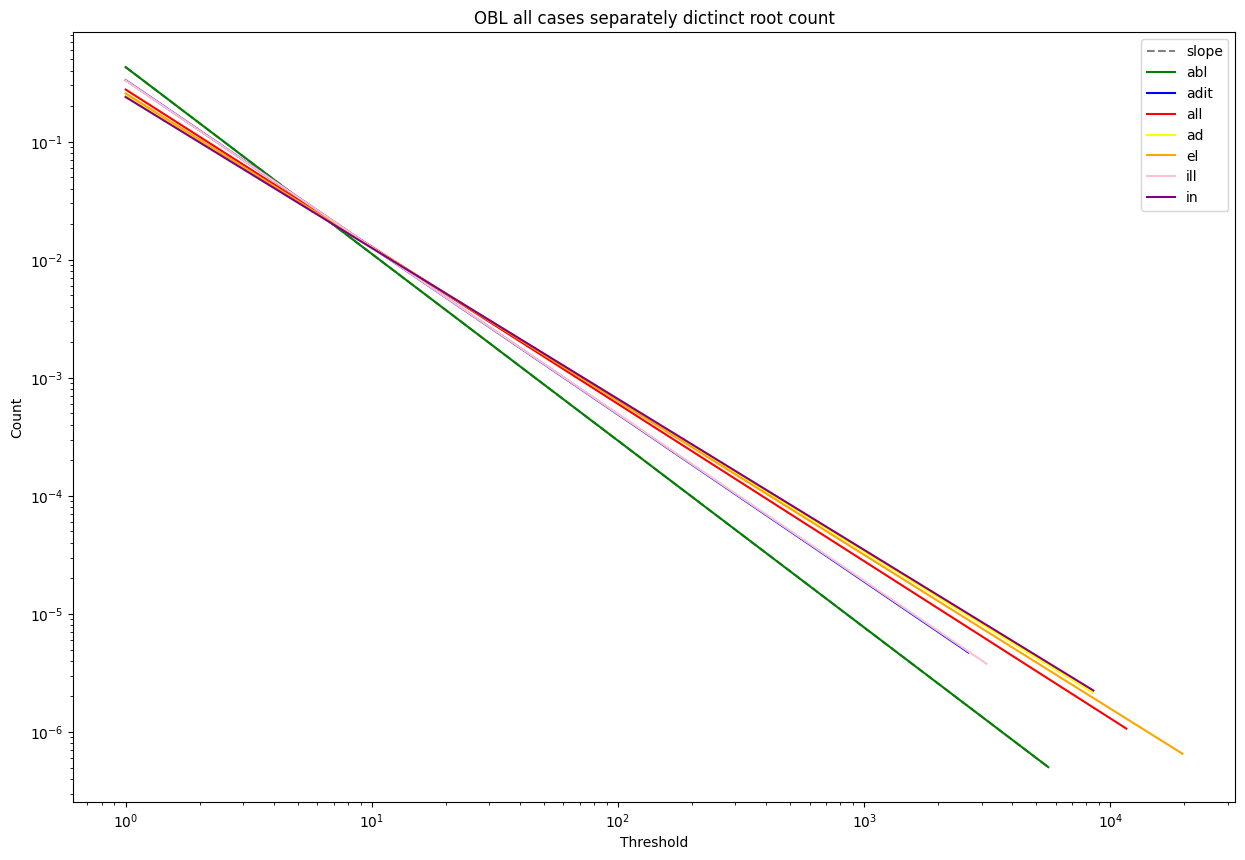

In [5]:
plt.figure(figsize=(15, 10))

fit1 = pwl.Fit(np.array(get_non_null(source,"abl_cnt")),xmin=1,discrete=True)
fit2 = pwl.Fit(np.array(get_non_null(source,"adit_cnt")),xmin=1,discrete=True)
fit3 = pwl.Fit(np.array(get_non_null(source,"all_cnt")),xmin=1,discrete=True)
fit4 = pwl.Fit(np.array(get_non_null(source,"ad_cnt")),xmin=1,discrete=True)
fit5 = pwl.Fit(np.array(get_non_null(source,"el_cnt")),xmin=1,discrete=True)
fit6 = pwl.Fit(np.array(get_non_null(source,"ill_cnt")),xmin=1,discrete=True)
fit7 = pwl.Fit(np.array(get_non_null(source,"in_cnt")),xmin=1,discrete=True)
fit1.power_law.plot_pdf( color= 'grey',linestyle='--',label='fit ccdf')
fit1.power_law.plot_pdf( color= 'green',label='abl')
fit2.power_law.plot_pdf( color= 'blue')
fit3.power_law.plot_pdf( color= 'red')
fit4.power_law.plot_pdf( color= 'yellow')
fit5.power_law.plot_pdf( color= 'orange')
fit6.power_law.plot_pdf( color= 'pink')
fit7.power_law.plot_pdf( color= 'purple')

plt.legend(['slope', 'abl', 'adit', "all", "ad", "el", "ill", "in"]) 

plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title('OBL all cases separately dictinct root count')
plt.show()

In [7]:
con.close()